<a href="https://colab.research.google.com/github/Ritesh-Gawande/Machine-Learning-Code/blob/main/Logistic_Placement_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
up = files.upload()

Saving student_dataset_10000_rows.csv to student_dataset_10000_rows.csv


In [5]:
df = pd.read_csv('student_dataset_10000_rows.csv')

In [7]:
df

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed
...,...,...,...,...,...,...,...,...
9995,2,58,9,7,8,88,69.31,Not Placed
9996,7,98,6,9,4,87,100.00,Placed
9997,10,44,8,5,10,37,95.94,Placed
9998,10,75,7,5,8,52,88.61,Placed


In [8]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  object 
dtypes: float64(1), int64(6), object(1)
memory usage: 625.1+ KB


In [10]:
df.isnull().sum()

,0
study_hours,0
attendance,0
sleep_hours,0
internet_usage,0
assignments_completed,0
previous_score,0
exam_score,0
placement_status,0


In [11]:
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [21]:
df.columns.unique()

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score',
       'placement_status'],
      dtype='object')

In [26]:
df.placement_status

,placement_status
0,Placed
1,Placed
2,Placed
3,Placed
4,Placed
...,...
9995,Not Placed
9996,Placed
9997,Placed
9998,Placed


In [27]:
df.placement_status =[1 if value == 'Placed' else 0 for value in df.placement_status]

In [28]:
df.placement_status

,placement_status
0,1
1,1
2,1
3,1
4,1
...,...
9995,0
9996,1
9997,1
9998,1


<Axes: >

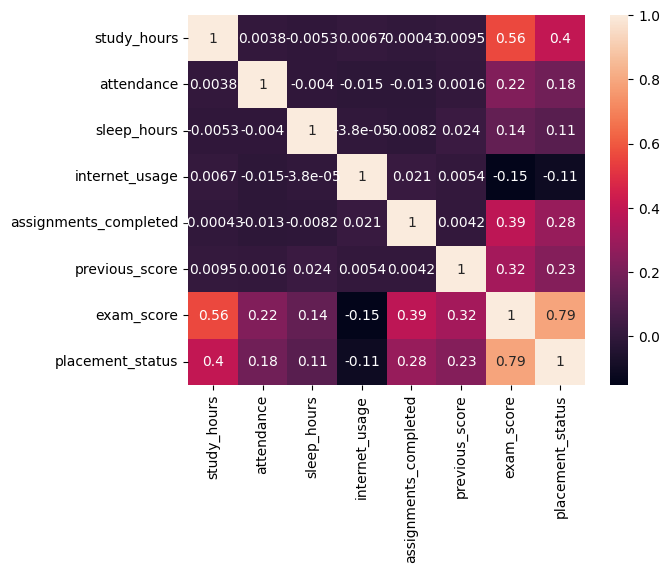

In [33]:
sns.heatmap(df.corr(),annot=True)

<Axes: xlabel='placement_status', ylabel='count'>

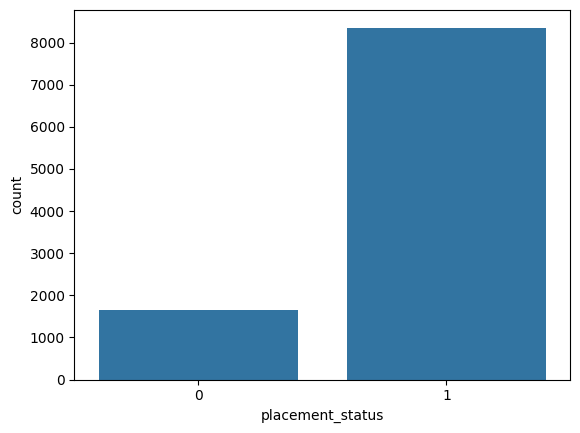

In [37]:
sns.barplot(df.placement_status.value_counts())

In [38]:
x = df.drop('placement_status',axis=1)
y = df['placement_status']

In [39]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=0)

In [43]:
x_train.columns

Index(['study_hours', 'attendance', 'sleep_hours', 'internet_usage',
       'assignments_completed', 'previous_score', 'exam_score'],
      dtype='object')

In [44]:
from sklearn.preprocessing import StandardScaler
sc =  StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [46]:
x_train , x_test

(array([[-0.00181688,  0.00248586, -1.46098077, ..., -1.32052838,
         -0.56478211, -1.35031478],
        [-1.26573509, -1.5839299 ,  0.87227194, ...,  1.33421691,
         -1.58960128, -0.34477706],
        [ 0.94612177, -0.73406432,  0.87227194, ..., -0.3249989 ,
         -1.36186369, -1.19444317],
        ...,
        [-0.31779643,  1.07898227, -0.87766759, ..., -0.3249989 ,
         -1.53266688, -1.64016965],
        [ 0.63014222, -0.79072202,  1.45558512, ..., -1.1546068 ,
          1.42792183,  0.88561375],
        [-0.00181688, -0.22414497,  1.45558512, ...,  0.83645217,
          0.68777465,  0.88561375]]),
 array([[ 1.26210133, -0.16748726, -0.29435441, ...,  0.50460901,
          0.40310266,  0.88561375],
        [-0.00181688,  1.4189285 , -0.29435441, ...,  0.83645217,
          0.91551224,  0.88561375],
        [ 0.31416267,  0.68237833,  0.87227194, ..., -1.32052838,
          0.63084025,  0.53274695],
        ...,
        [-1.58171464, -1.5272722 , -1.46098077, ...,  

In [47]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [48]:
y_pred = lr.predict(x_test)

In [50]:
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
ac = accuracy_score(y_test,y_pred)*100
ac

cm = confusion_matrix(y_test,y_pred)
cm

array([[ 320,    3],
       [   2, 1675]])

In [54]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       323
           1       1.00      1.00      1.00      1677

    accuracy                           1.00      2000
   macro avg       1.00      0.99      1.00      2000
weighted avg       1.00      1.00      1.00      2000

